SEMESTER 1 

FINAL PROJECT  

TASK 1: Clean and Validate the Salary Data

In [1]:
'''Start by examining and cleaning the dataset. Some records contain missing or inconsistent values.
You should start with the data in the file "ds_salaries_dirty.csv".


Your output should be a DataFrame named clean_salaries.'''

'Start by examining and cleaning the dataset. Some records contain missing or inconsistent values.\nYou should start with the data in the file "ds_salaries_dirty.csv".\n\n\nYour output should be a DataFrame named clean_salaries.'

In [2]:
#Loading data and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dirty_data=r'C:\Users\MURERWA DANIEL\Documents\GitHub\DataScience\Data_Dataset\ds_salaries_dirty.csv'
df=pd.read_csv(dirty_data)
df.head(10)

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2022,SE,CT,Data Scientist,42183.0,50,IN,L
1,2023,MI,FL,Data Scientist,190371.0,100,IN,S
2,2020,MI,CT,DS,173946.0,50,IN,L
3,2022,NaN,FT,ML Engineer,146336.0,50,DE,S
4,2022,MI,FL,ML Engineer,9999999.0,100,NG,L
5,2023,MI,FT,Data Scientist,35539.0,50,GB,S
6,2020,NaN,FL,AI Specialist,214423.0,100,DE,XL
7,2020,EX,FL,ML Engineer,222339.0,50,IN,S
8,2022,MI,PT,DS,209426.0,100,US,S
9,2021,SE,FT,ML Engineer,5000000.0,100,IN,M


Work year

In [3]:
work_year=df[df['work_year'].notnull()]
df['work_year'].isnull().sum()

np.int64(0)

Experience Level

In [4]:
df['experience_level'].isnull().sum()


np.int64(10)

In [5]:
df['experience_level'].fillna('EN', inplace=True)

C:\Users\MURERWA DANIEL\AppData\Local\Temp\ipykernel_6840\2021161717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['experience_level'].fillna('EN', inplace=True)


In [6]:
df['experience_level'].isnull().sum()

np.int64(0)

Employment Type

In [7]:
df['employment_type'].isnull().sum()

np.int64(8)

In [8]:
df['employment_type'].fillna('FT', inplace=True)


C:\Users\MURERWA DANIEL\AppData\Local\Temp\ipykernel_6840\556661681.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['employment_type'].fillna('FT', inplace=True)


In [9]:
df['employment_type'].isnull().sum()

np.int64(0)

Job Title

In [10]:
print(df['job_title'].dtype)
length=df['job_title'].astype(str).str.len()
print(f'Minimum length is: {length.min()} and Maximum length is: {length.max()}')

object
Minimum length is: 2 and Maximum length is: 14


In [11]:
df=df[length>=3]
df['job_title'].shape

(95,)

Salaries in USD

In [12]:
print(df['salary_in_usd'].dtype)
salary_str = df['salary_in_usd'].astype(str)
num_digits = salary_str.str.len()
print(f"Maximum digits: {num_digits.max()} and Minimum digits: {num_digits.min()}")

float64
Maximum digits: 9 and Minimum digits: 3


In [13]:
median_salary= df['salary_in_usd'].median()
median_salary

154019.0

In [14]:
df.loc[(df['salary_in_usd']>1000000)|(df["salary_in_usd"]<10000), 'salary_in_usd' ]=median_salary

Company Location

In [15]:
df['company_location'].isnull().sum()

np.int64(5)

In [16]:
df['company_location'].fillna('US', inplace=True)

C:\Users\MURERWA DANIEL\AppData\Local\Temp\ipykernel_6840\3718128228.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['company_location'].fillna('US', inplace=True)


In [17]:
df = df[df['company_location'].astype(str).str.len() == 2]

Company Size

In [18]:
valid_sizes = ['S', 'M', 'L']
df['company_size'] = df['company_size'].where(df['company_size'].isin(valid_sizes), 'M')


In [19]:
df.head(20)

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2022,SE,CT,Data Scientist,42183.0,50,IN,L
1,2023,MI,FL,Data Scientist,190371.0,100,IN,S
3,2022,EN,FT,ML Engineer,146336.0,50,DE,S
4,2022,MI,FL,ML Engineer,154019.0,100,NG,L
5,2023,MI,FT,Data Scientist,35539.0,50,GB,S
6,2020,EN,FL,AI Specialist,214423.0,100,DE,M
7,2020,EX,FL,ML Engineer,222339.0,50,IN,S
9,2021,SE,FT,ML Engineer,154019.0,100,IN,M
10,2022,EX,CT,AI Specialist,163629.0,50,US,S
11,2022,SE,CT,Data Analyst,68360.0,50,IN,M


In [20]:
clean_salaries = df.copy()
clean_salaries.to_csv('clean_salaries.csv', index=False)

TASK 2: Salary Trends by Experience

In [21]:
'''Investigate how experience level affects average salary across employment types.
Group the data by experience_level and employment_type, and note observations in markdown.


Compute average salary_in_usd.


Your result should be a DataFrame named salary_trends and
 Notes stating your findings in markdown
'''

'Investigate how experience level affects average salary across employment types.\nGroup the data by experience_level and employment_type, and note observations in markdown.\n\n\nCompute average salary_in_usd.\n\n\nYour result should be a DataFrame named salary_trends and\n Notes stating your findings in markdown\n'

In [22]:
clean_salaries=r'C:\Users\MURERWA DANIEL\Documents\GitHub\DataScience\Assignments\clean_salaries.csv'
df=pd.read_csv(clean_salaries)

In [23]:
# Group by experience_level and employment_type, then compute the mean salary
salary_trends = df.groupby(['experience_level', 'employment_type'])['salary_in_usd'].mean().reset_index()
salary_trends

,experience_level,employment_type,salary_in_usd
0,EN,CT,77025.250000
1,EN,FL,160093.333333
2,EN,FT,132732.444444
3,EN,PT,166740.000000
4,EX,CT,166817.200000
5,EX,FL,163361.250000
6,EX,FT,175002.625000
7,EX,PT,68467.000000
8,MI,CT,170696.750000
9,MI,FL,128410.250000


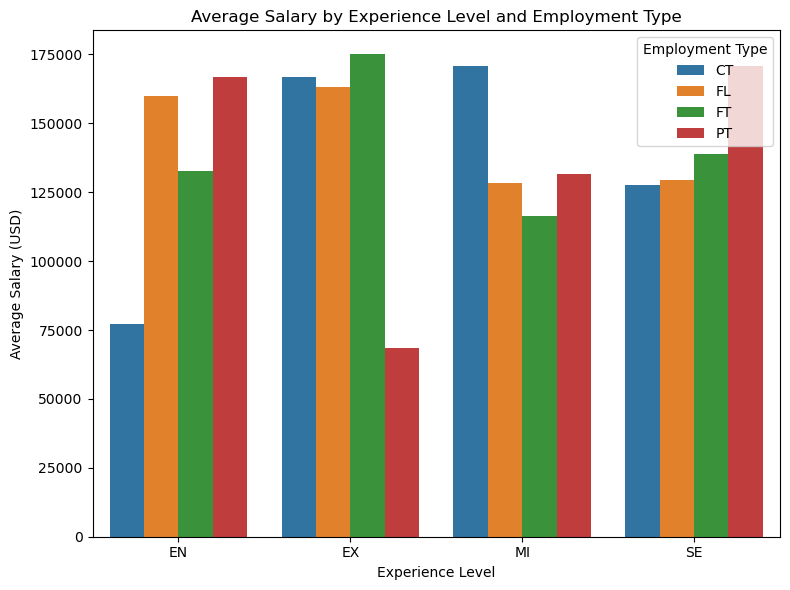

In [24]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=salary_trends,
    x='experience_level',
    y='salary_in_usd',
    hue='employment_type'
)
plt.title('Average Salary by Experience Level and Employment Type')
plt.ylabel('Average Salary (USD)')
plt.xlabel('Experience Level')
plt.legend(title='Employment Type')
plt.tight_layout()
plt.show()

1. Full-time (FT) roles generally offer higher average salaries compared to part-time (PT), contract(CT), or freelance (FL) roles.
2. Entry-level (EN) positions have the lowest average salaries.
3. Higher experience levels (eg. EX) have higher average salaries across all employment types.
4. 

TASK 3: Remote Work Analysis

In [25]:
'''Analyze and discuss the effect of remote work on salaries.
Compare average salaries between remote (remote_ratio = 100) and non-remote (remote_ratio = 0) roles.


Output should be a DataFrame named remote_salary_comparison with two rows:


Remote


On-site
 '''

'Analyze and discuss the effect of remote work on salaries.\nCompare average salaries between remote (remote_ratio = 100) and non-remote (remote_ratio = 0) roles.\n\n\nOutput should be a DataFrame named remote_salary_comparison with two rows:\n\n\nRemote\n\n\nOn-site\n '

In [26]:
df['work_type'] = df['remote_ratio'].apply(lambda x: 'Remote' if x == 100 else ('On-site' if x == 0 else 'Hybrid'))
remote_salary_comparison = df[df['work_type'].isin(['Remote', 'On-site'])].groupby('work_type')['salary_in_usd'].mean().reset_index()
remote_salary_comparison

,work_type,salary_in_usd
0,On-site,153214.04000
1,Remote,144734.37037
